Autoencoders


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.27MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 165kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.55MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.21MB/s]


In [3]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 28*28)
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon.view(-1, 1, 28, 28)

model = Autoencoder()

In [4]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    for images, _ in dataloader:

        # Add noise
        noisy = images + 0.3 * torch.randn_like(images)
        noisy = torch.clamp(noisy, 0., 1.)

        output = model(noisy)
        loss = criterion(output, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.0362
Epoch 2, Loss: 0.0308
Epoch 3, Loss: 0.0259
Epoch 4, Loss: 0.0194
Epoch 5, Loss: 0.0199


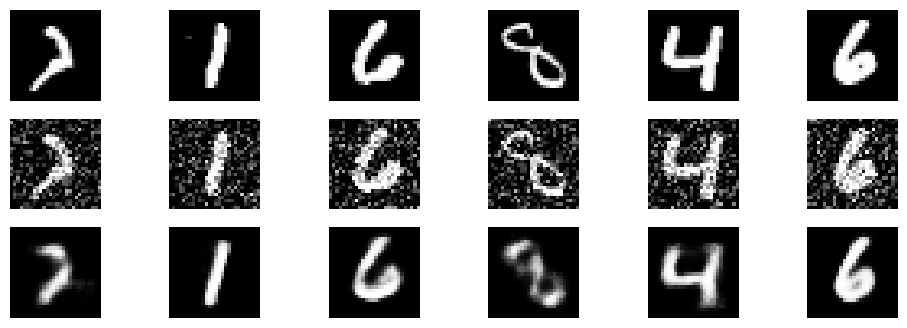

In [5]:
images, _ = next(iter(dataloader))
noisy = images + 0.3 * torch.randn_like(images)
noisy = torch.clamp(noisy, 0., 1.)

output = model(noisy)

plt.figure(figsize=(12,4))

for i in range(6):
    plt.subplot(3,6,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.axis('off')

    plt.subplot(3,6,i+7)
    plt.imshow(noisy[i][0], cmap='gray')
    plt.axis('off')

    plt.subplot(3,6,i+13)
    plt.imshow(output[i][0].detach(), cmap='gray')
    plt.axis('off')

plt.show()

VAE

In [6]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, 20)
        self.fc_logvar = nn.Linear(400, 20)

        self.fc2 = nn.Linear(20, 400)
        self.fc3 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        x = x.view(-1, 784)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE()

In [7]:
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(
        recon_x, x.view(-1, 784), reduction='sum'
    )
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [8]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    for images, _ in dataloader:

        recon, mu, logvar = model(images)
        loss = loss_function(recon, images, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 12430.0977
Epoch 2, Loss: 10869.6094
Epoch 3, Loss: 10863.9229
Epoch 4, Loss: 10266.6943
Epoch 5, Loss: 10288.7852


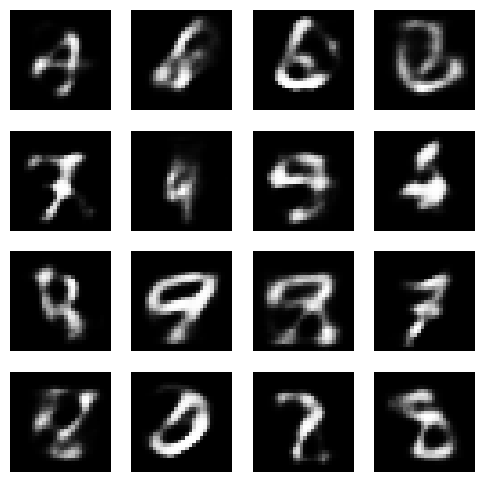

In [9]:
with torch.no_grad():
    z = torch.randn(16, 20)
    sample = model.decode(z).view(-1,1,28,28)

plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(sample[i][0], cmap='gray')
    plt.axis('off')

plt.show()